# Do higher-poverty countries receive more Kiva loans and higher loans per capita than lower-poverty countries?
ECO225 – Project 1  
Kexing Yan  
Professor Khazra
Date: 2026-2-4

## 1. Introduction
Microfinance is widely viewed as a tool for expanding credit access among low-income populations, yet the literature shows that outreach is shaped not only by poverty but also by institutional and financial constraints. Studies of microfinance institutions document a tradeoff between serving poorer clients and maintaining efficiency and profitability, suggesting that reaching the very poorest borrowers can be costly and operationally difficult (Cull, Demirgüç-Kunt, and Morduch, 2007; Hermes, Lensink, and Meesters, 2011). At the same time, industry-level evidence highlights how commercialization and market structure influence where microfinance can scale, implying that financial development may condition outreach (Cull, Demirgüç-Kunt, and Morduch, 2009).

Other work emphasizes the importance of local financial infrastructure. Quasi-experimental evidence shows that expanding bank branches increases credit availability and reduces poverty (Burgess and Pande, 2005), while studies of urban microcredit markets demonstrate that borrowing behavior depends on the surrounding financial environment (Dehejia, Montgomery, and Morduch, 2012). Together, these findings suggest that poverty alone may not determine lending patterns; instead, financial access may act as a key mechanism linking economic need to credit outcomes.

Motivated by this literature, this project examines whether higher-poverty countries receive more Kiva loans per capita and whether cross-country differences in financial access help explain variation in lending intensity.

## 2. Data Cleaning/Loading

I use a pre-constructed country-level dataset:

`outputs/country_master_with_finance.csv`

Each row represents one country. The dataset combines aggregated Kiva lending outcomes with poverty measures and World Bank indicators of financial access.

In this notebook, I load the merged data, construct per-capita lending variables, create poverty terciles, and build a financial access index to study how poverty (X) relates to lending outcomes (Y) and whether financial infrastructure (Z) helps explain cross-country differences.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from stargazer.stargazer import Stargazer
from IPython.display import display, HTML

# Load merged country dataset (Kiva + poverty + World Bank financial access)
df = pd.read_csv("outputs/country_master_with_finance.csv")
df.columns = df.columns.str.strip()

# Ensure numeric columns
for c in ["population", "n_loans", "total_loan_amount", "poverty_rate", "financial_access_index"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Per-capita outcomes
df.loc[df["population"] <= 0, "population"] = np.nan
df["loans_per_capita"] = df["n_loans"] / df["population"]
df["loan_amount_per_capita"] = df["total_loan_amount"] / df["population"]

# Poverty terciles
df["poverty_tercile"] = pd.NA
m = df["poverty_rate"].notna()
df.loc[m, "poverty_tercile"] = pd.qcut(
    df.loc[m, "poverty_rate"],
    q=3,
    labels=["Low poverty", "Medium poverty", "High poverty"]
)

# Financial access split (median split)
df["Z_split"] = pd.NA
if "financial_access_index" in df.columns:
    z = pd.to_numeric(df["financial_access_index"], errors="coerce")
    z_med = z.median(skipna=True)
    mz = z.notna()
    df.loc[mz & (z >= z_med), "Z_split"] = "High-Z"
    df.loc[mz & (z <  z_med), "Z_split"] = "Low-Z"


In [20]:
# Poverty terciles (subgroups)
df["poverty_tercile"] = pd.NA
m = df["poverty_rate"].notna()
df.loc[m, "poverty_tercile"] = pd.qcut(
    df.loc[m, "poverty_rate"],
    q=3,
    labels=["Low poverty", "Medium poverty", "High poverty"]
)

# Z split (median split) for heterogeneity
# UPDATED: Z = financial_access_index (NOT urban_rural_gap)
df["Z_split"] = pd.NA
if "financial_access_index" in df.columns:
    z_med = pd.to_numeric(df["financial_access_index"], errors="coerce").median(skipna=True)
    mz = pd.to_numeric(df["financial_access_index"], errors="coerce").notna()
    df.loc[mz & (df["financial_access_index"] >= z_med), "Z_split"] = "High-Z"
    df.loc[mz & (df["financial_access_index"] <  z_med), "Z_split"] = "Low-Z"


I focus on one main outcome and a small set of explanatory variables motivated by the economic mechanism. The outcome (Y) is loans per capita, which measures the intensity of Kiva lending at the country level. The key explanatory variable (X) is the poverty rate. To capture the proposed mechanism (Z), I construct a financial access index using World Bank measures of bank branches, ATMs, and account ownership.

The intuition is that poverty may create demand for microfinance, while financial infrastructure may determine whether lending can operate effectively. Thus, both poverty and financial access are expected to shape cross-country differences in Kiva lending.

## 3. Summary Statistics Tables

This section reports summary statistics for the outcome variable (loans per capita) and the explanatory variables. I first report overall summary statistics, then provide subgroup summaries by poverty tercile to examine whether high-poverty countries differ systematically in Kiva lending outcomes and in the proposed mechanism variables.

In [21]:
# Table 1. Summary Statistics (Stargazer)

cols = [
    "loans_per_capita",
    "loan_amount_per_capita",
    "poverty_rate",
    "financial_access_index",
    "bank_branches_per_100k",
    "atms_per_100k",
    "bank_accounts_per_1000",
    "credit_private_gdp"
]

# Convert to numeric safely (keep missing as NaN)
for c in cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    else:
        df[c] = np.nan

models = []
stats = {"SD": [], "Min": [], "Median": [], "Max": [], "N": []}

for c in cols:
    y = df[c]

    y_nonmissing = y.dropna()
    stats["N"].append(str(len(y_nonmissing)))
    stats["SD"].append(f"{y_nonmissing.std():.4f}" if len(y_nonmissing) > 1 else "NA")
    stats["Min"].append(f"{y_nonmissing.min():.4f}" if len(y_nonmissing) > 0 else "NA")
    stats["Median"].append(f"{y_nonmissing.median():.4f}" if len(y_nonmissing) > 0 else "NA")
    stats["Max"].append(f"{y_nonmissing.max():.4f}" if len(y_nonmissing) > 0 else "NA")

    X = pd.DataFrame({"const": 1}, index=y.index)
    m = sm.OLS(y, X, missing="drop").fit()
    models.append(m)

sg = Stargazer(models)
sg.title("Table 1. Summary Statistics (Stargazer)")
sg.custom_columns(cols, [1]*len(cols))
sg.dependent_variable_name("Variable")

sg.covariate_order(["const"])
sg.rename_covariates({"const": "Mean"})

sg.add_line("SD", stats["SD"])
sg.add_line("Min", stats["Min"])
sg.add_line("Median", stats["Median"])
sg.add_line("Max", stats["Max"])
sg.add_line("N", stats["N"])

display(HTML(sg.render_html()))


**Interpretation (Table 1).**  
Table 1 shows substantial cross-country variation in both poverty and lending. Loans per capita are highly right-skewed, with most countries receiving very small amounts of lending and a few countries receiving much larger volumes. The financial access index is approximately standardized and displays wide dispersion, indicating meaningful differences in banking development across countries. These patterns suggest that both poverty and financial infrastructure may help explain differences in Kiva activity.

In [22]:
# Table 2. Group Means by Poverty Tercile (Stargazer)

outcomes = ["loans_per_capita", "loan_amount_per_capita"]
groups = ["Low poverty", "Medium poverty", "High poverty"]

df_g = df.dropna(subset=["poverty_tercile"]).copy()

models = []
col_names = []
stats = {"SD": [], "Min": [], "Median": [], "Max": [], "N": []}

for g in groups:
    dg = df_g[df_g["poverty_tercile"] == g].copy()

    for yname in outcomes:
        y = pd.to_numeric(dg[yname], errors="coerce")

        y_nonmissing = y.dropna()
        stats["N"].append(str(len(y_nonmissing)))

        if len(y_nonmissing) == 0:
            stats["SD"].append("NA")
            stats["Min"].append("NA")
            stats["Median"].append("NA")
            stats["Max"].append("NA")
        else:
            stats["SD"].append(f"{y_nonmissing.std():.4f}" if len(y_nonmissing) > 1 else "NA")
            stats["Min"].append(f"{y_nonmissing.min():.4f}")
            stats["Median"].append(f"{y_nonmissing.median():.4f}")
            stats["Max"].append(f"{y_nonmissing.max():.4f}")

        X = pd.DataFrame({"const": 1}, index=dg.index)
        m = sm.OLS(y, X, missing="drop").fit()
        models.append(m)

        col_names.append(f"{g}: {yname}")

sg2 = Stargazer(models)
sg2.title("Table 2. Group Means by Poverty Tercile (Stargazer)")
sg2.custom_columns(col_names, [1] * len(col_names))
sg2.dependent_variable_name("Outcome")

sg2.covariate_order(["const"])
sg2.rename_covariates({"const": "Mean"})

sg2.add_line("SD", stats["SD"])
sg2.add_line("Min", stats["Min"])
sg2.add_line("Median", stats["Median"])
sg2.add_line("Max", stats["Max"])
sg2.add_line("N", stats["N"])

display(HTML(sg2.render_html()))


**Interpretation (Table 2).**  
Table 1 shows substantial cross-country variation in both poverty and lending. Loans per capita are highly right-skewed, with most countries receiving very small amounts of lending and a few countries receiving much larger volumes. The financial access index is approximately standardized and displays wide dispersion, indicating meaningful differences in banking development across countries. These patterns suggest that both poverty and financial infrastructure may help explain differences in Kiva activity.

## 4. Plots, Histograms, Figures

This section presents visual evidence on (i) the distribution of key variables, (ii) the relationship between poverty and Kiva lending outcomes, and (iii) heterogeneity across countries with different levels of financial access. Each figure is briefly interpreted in relation to the research question.

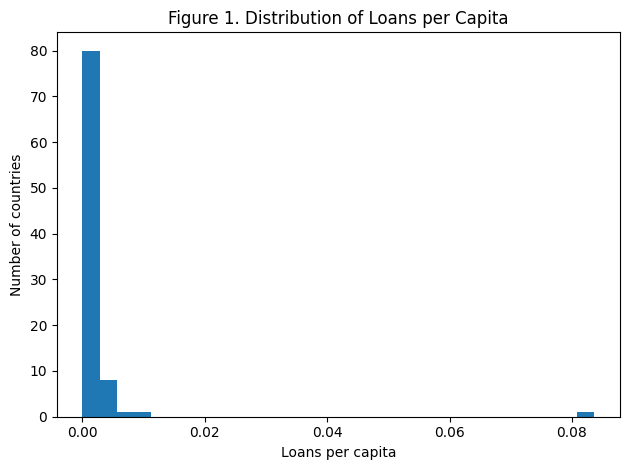

In [23]:
plt.figure()
plt.hist(df["loans_per_capita"].dropna(), bins=30)
plt.title("Figure 1. Distribution of Loans per Capita")
plt.xlabel("Loans per capita")
plt.ylabel("Number of countries")
plt.tight_layout()
plt.show()


**Figure 1 interpretation.**  
Figure 1 shows that loans per capita are strongly right-skewed, with most countries clustered near zero. This motivates comparing groups rather than relying only on averages.

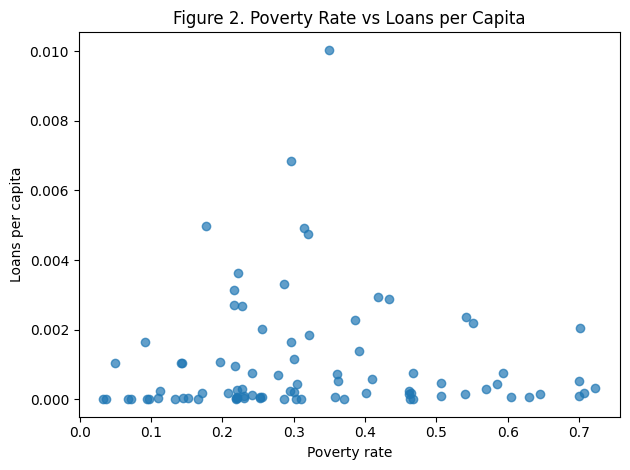

In [24]:
plt.figure()
plt.scatter(df["poverty_rate"], df["loans_per_capita"], alpha=0.7)
plt.title("Figure 2. Poverty Rate vs Loans per Capita")
plt.xlabel("Poverty rate")
plt.ylabel("Loans per capita")
plt.tight_layout()
plt.show()


**Figure 2 interpretation.**  
Figure 2 plots poverty against loans per capita and shows no clear linear relationship. Instead, lending appears highest for countries with intermediate poverty levels.

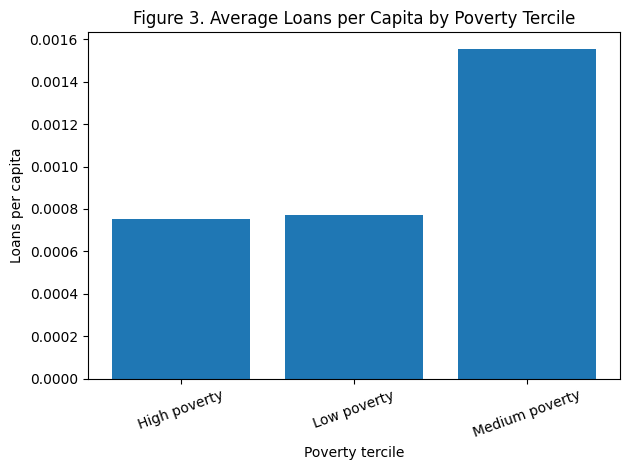

In [25]:
g = (
    df.dropna(subset=["poverty_tercile", "loans_per_capita"])
      .groupby("poverty_tercile", observed=False)["loans_per_capita"]
      .mean()
)

plt.figure()
plt.bar(g.index.astype(str), g.values)
plt.title("Figure 3. Average Loans per Capita by Poverty Tercile")
plt.xlabel("Poverty tercile")
plt.ylabel("Loans per capita")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Figure 3 interpretation.**  
Figure 3 confirms this pattern: medium-poverty countries have the highest average lending, while both low- and high-poverty countries receive less.

In [26]:
df4 = df.dropna(subset=["poverty_tercile", "Z_split", "loans_per_capita"]).copy()

pivot = df4.pivot_table(
    index="poverty_tercile",
    columns="Z_split",
    values="loans_per_capita",
    aggfunc="mean",
    observed=False
).round(4)

pivot

Z_split,High-Z,Low-Z
poverty_tercile,,
High poverty,0.0007,0.0008
Low poverty,0.0004,0.0017
Medium poverty,0.0021,0.0012


<Figure size 640x480 with 0 Axes>

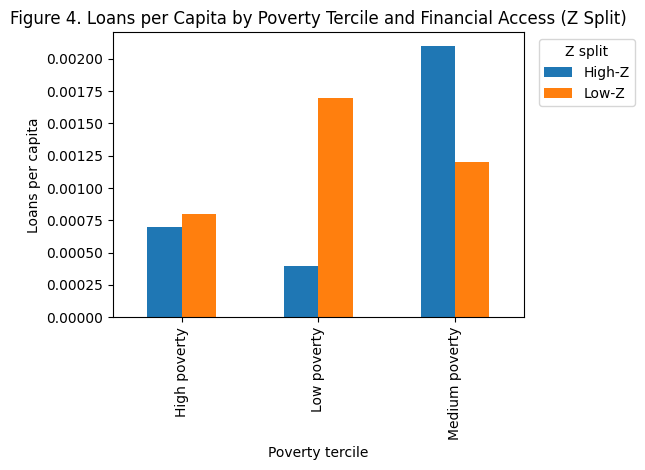

In [27]:
pivot_plot = pivot.copy()

plt.figure()
pivot_plot.plot(kind="bar")
plt.title("Figure 4. Loans per Capita by Poverty Tercile and Financial Access (Z Split)")
plt.xlabel("Poverty tercile")
plt.ylabel("Loans per capita")
plt.legend(title="Z split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Figure 4 interpretation.**  
Figure 4 introduces the financial access mechanism. Within medium-poverty countries, those with higher financial access receive more lending, suggesting that infrastructure complements microfinance. In low-poverty countries, higher access is associated with less Kiva lending, consistent with substitution by formal banking. For high-poverty countries, differences are small. These results indicate that financial access affects where microfinance is most effective rather than uniformly increasing lending.

## 5. Conclusion

This project finds that Kiva lending is not concentrated in the poorest countries. Instead, lending peaks in medium-poverty countries and depends on financial infrastructure. Financial access appears to complement microfinance where basic institutions exist but may substitute for it in more developed countries. Overall, the descriptive evidence suggests that both poverty and institutional capacity jointly shape microfinance allocation. Future work could examine these relationships more formally using causal methods.